# 3-Oscillator Mutually Coupled DVP System — Chaotic Regime Search
## Equations of motion
$$\dot{x_i} = v_i$$
$$\dot{v_i} = -\mu_i(x_i^2 - 1)v_i - \omega_i^2 x_i - \alpha_i x_i^3 - \sum_{j \neq i} k_{ij}(x_i - x_j) + F_i \cos(\Omega t)$$
for $i \in \{1,2,3\}$ with all-to-all coupling $k_{12}, k_{13}, k_{23}$.

State vector: $[x_1, v_1, x_2, v_2, x_3, v_3]$ (6D)

In [26]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 100000

from ExperimentTracker import ExperimentTracker
from time import time
from Logger import Logger
import ipynbname
import os

NOTEBOOK_NAME = ipynbname.name()
OP_DIR = os.path.abspath(os.path.join(os.path.curdir, "Outputs-3_Oscillator"))

from Helpers import read_json_config, time_format
PARAM_CONFIG_DIR = os.path.join(os.path.curdir, "3OscDVPParams.config")
PARAMS = read_json_config(PARAM_CONFIG_DIR)


tracker = ExperimentTracker(OP_DIR)

LINE_WIDTH = 0.15
DPI = 750
DOT_RADIUS = 0.5
ASPECT_RATIO_INV = 1

In [27]:
def dvp_3osc_coupled(t, state, params):
    x1, v1, x2, v2, x3, v3 = state
    p = params
    cos_Ot = np.cos(p['Omega'] * t)

    dx1 = v1
    dv1 = (-p['mu1'] * (x1**2 - 1) * v1
            - p['omega1']**2 * x1
            - p['alpha1'] * x1**3
            - p['k12'] * (x1 - x2) - p['k13'] * (x1 - x3)
            + p['F1'] * cos_Ot)

    dx2 = v2
    dv2 = (-p['mu2'] * (x2**2 - 1) * v2
            - p['omega2']**2 * x2
            - p['alpha2'] * x2**3
            - p['k12'] * (x2 - x1) - p['k23'] * (x2 - x3)
            + p['F2'] * cos_Ot)

    dx3 = v3
    dv3 = (-p['mu3'] * (x3**2 - 1) * v3
            - p['omega3']**2 * x3
            - p['alpha3'] * x3**3
            - p['k13'] * (x3 - x1) - p['k23'] * (x3 - x2)
            + p['F3'] * cos_Ot)

    return [dx1, dv1, dx2, dv2, dx3, dv3]

In [28]:
def simulate(params=None, x0=None, t_span=(0, 200), ts_per_sec=100, verbose=True):
    if params is None:
        params = PARAMS
    if x0 is None:
        x0 = [0.1, 0.0, -0.1, 0.0, 0.05, 0.0]
        x0 = np.random.uniform(low=2.0, high=10.0, size=6)
        

    t_eval = np.arange(t_span[0], t_span[1], 1/ts_per_sec)
    start_time = time()

    sol = solve_ivp(
        fun=lambda t, y: dvp_3osc_coupled(t, y, params),
        t_span=t_span,
        y0=x0,
        t_eval=t_eval,
        method='RK45',
        rtol=1e-9,
        atol=1e-9,
        dense_output=False
    )

    duration = time() - start_time
    msg = ""
    if verbose:
        msg += (f"Simulated {(t_span[1] - t_span[0])*ts_per_sec:.0f} steps for {len(x0)} states in [{time_format(duration)}].")
        msg += ("\nParameters:")
        for key, value in params.items():
            msg += (f"\n\t{key:20} {value}")
    return sol.t, sol.y, msg

def drop_transient(t, sol, frac=0.3):
    n = int(len(t) * frac)
    return t[n:], sol[:, n:]

def plot_phase_portrait(sol, title="Phase Portrait", save_path=None):
    global OP_DIR, NOTEBOOK_NAME
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, ax in enumerate(axes):
        ax.plot(sol[2*i], sol[2*i + 1], lw=LINE_WIDTH, color='steelblue', alpha=0.8)
        ax.set_xlabel(f'$x_{i+1}$')
        ax.set_ylabel(f'$\\frac{{dx_{i+1}}}{{dt}}$')
        ax.set_title(f'Oscillator {i+1}')
        ax.grid(True, alpha=0.3)
        ax.set_box_aspect(ASPECT_RATIO_INV)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    save_path = "" if save_path is None else save_path
    fig.savefig(os.path.join(save_path, f"{NOTEBOOK_NAME}_out_FP.png"), dpi=DPI)

def plot_poincare(ps, title="Poincare Section", save_path=None):
    global OP_DIR, NOTEBOOK_NAME
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, ax in enumerate(axes):
        ax.scatter(ps[2*i], ps[2*i + 1], s=DOT_RADIUS, color='crimson', alpha=0.7)
        ax.set_xlabel(f'$x_{i+1}$')
        ax.set_ylabel(f'$\\frac{{dx_{i+1}}}{{dt}}$')
        ax.set_title(f'Oscillator {i+1}')
        ax.grid(True, alpha=0.3)
        ax.set_box_aspect(ASPECT_RATIO_INV)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()
    save_path = "" if save_path is None else save_path
    fig.savefig(os.path.join(save_path, f"{NOTEBOOK_NAME}_out_PS.png"), dpi=DPI)

def poincare_section(t, sol, params, dt=0.01, transient_frac=0.3):
    T = 2 * np.pi / params['Omega']
    period_steps = int(round(T / dt))
    n_drop = int(len(t) * transient_frac)
    sol_trimmed = sol[:, n_drop:]
    indices = np.arange(0, sol_trimmed.shape[1], period_steps)
    return sol_trimmed[:, indices]

In [29]:
def compute_mle(params, x0=None, t_span=(0, 500), ts_per_sec=100,
             eps=1e-8, renorm_interval=10, transient_frac=0.2, verbose=False):
    if x0 is None:
        x0 = [0.1, 0.0, -0.1, 0.0, 0.05, 0.0]

    dt = 1 / ts_per_sec
    renorm_steps = int(renorm_interval * ts_per_sec)

    t_full, sol_full, msg = simulate(params=params, x0=x0,
                                t_span=t_span, ts_per_sec=ts_per_sec, verbose=verbose)
    n_drop = int(len(t_full) * transient_frac)
    x_ref = sol_full[:, n_drop]

    x_pert = x_ref.copy()
    x_pert[0] += eps

    lyapunov_sum = 0.0
    n_renorm = 0
    growth_log = []
    t_current = t_full[n_drop]

    while t_current < t_span[1]:
        t_end = min(t_current + renorm_interval, t_span[1])

        sol_ref = solve_ivp(
            fun=lambda t, y: dvp_3osc_coupled(t, y, params),
            t_span=(t_current, t_end),
            y0=x_ref,
            method='RK45', rtol=1e-9, atol=1e-9,
            dense_output=False
        )
        sol_per = solve_ivp(
            fun=lambda t, y: dvp_3osc_coupled(t, y, params),
            t_span=(t_current, t_end),
            y0=x_pert,
            method='RK45', rtol=1e-9, atol=1e-9,
            dense_output=False
        )

        x_ref  = sol_ref.y[:, -1]
        x_pert = sol_per.y[:, -1]

        delta = x_pert - x_ref
        delta_norm = np.linalg.norm(delta)

        if delta_norm == 0:
            break

        lyapunov_sum += np.log(delta_norm / eps)
        n_renorm += 1
        x_pert = x_ref + eps * (delta / delta_norm)
        t_current = t_end

        mle_running = lyapunov_sum / (n_renorm * renorm_interval)
        growth_log.append((t_current, mle_running))

    mle_final = lyapunov_sum / (n_renorm * renorm_interval)
    return mle_final, np.array(growth_log)

def plot_mle_convergence(growth_log, mle_final, title="MLE Convergence", save_path=None):
    global OP_DIR, NOTEBOOK_NAME
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(growth_log[:, 0], growth_log[:, 1], lw=1.0, color='darkorange')
    ax.axhline(y=mle_final, color='crimson', lw=1.0, linestyle='--', label=f'MLE = {mle_final:.4f}')
    ax.axhline(y=0, color='gray', lw=0.8, linestyle=':')
    ax.set_xlabel('Time')
    ax.set_ylabel('Running MLE estimate')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    save_path = "" if save_path is None else save_path
    fig.savefig(os.path.join(save_path, f"{NOTEBOOK_NAME}_out_MLE.png"), dpi=300)

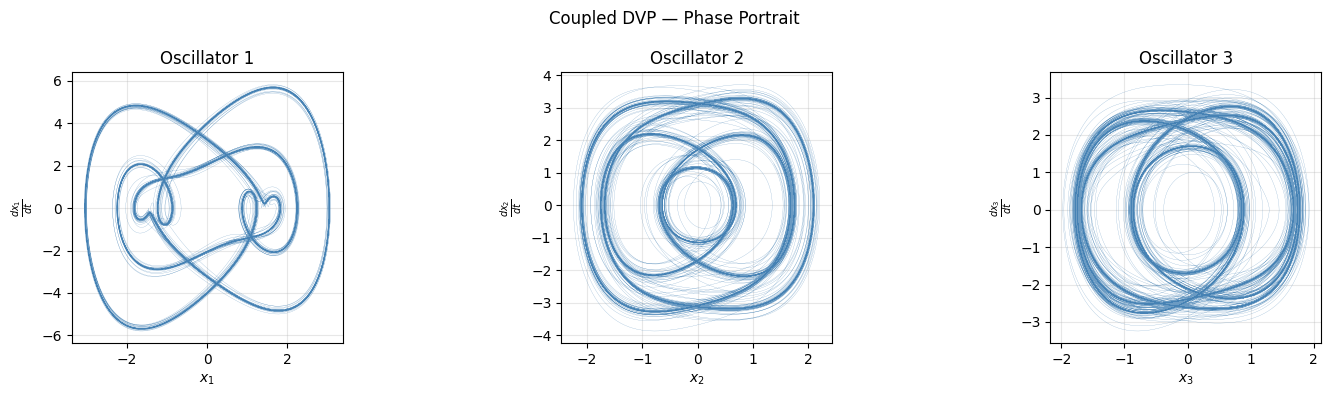

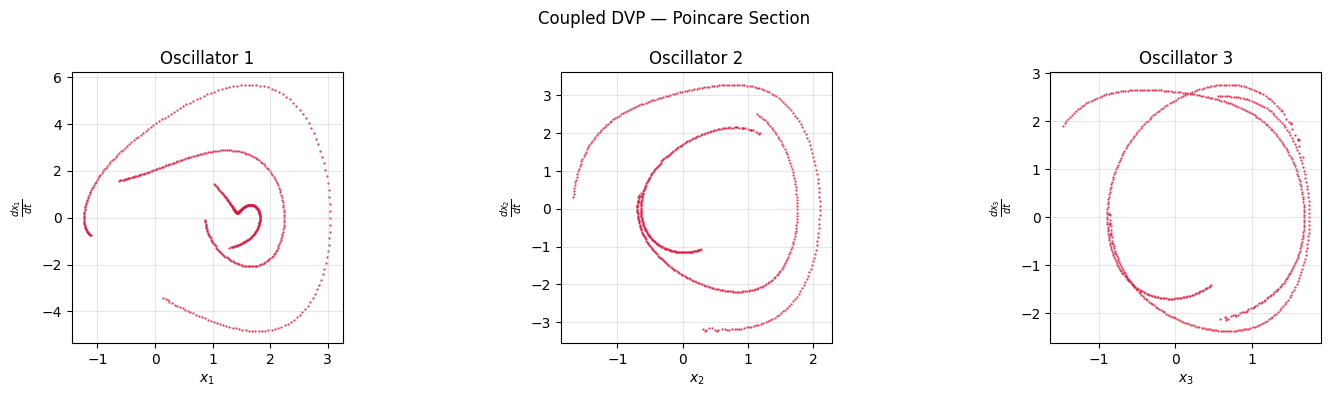

Logger initialized with file 2026-04-02_15-56-07_ed66e22b1d.log
[2026-04-02 15:56:58] [INFO] [DEF]: Simulated 500000 steps for 6 states in [0.0 hrs 0.0 mins 21.38 secs].
[2026-04-02 15:56:58] [INFO] [DEF]: Parameters:
[2026-04-02 15:56:58] [INFO] [DEF]: 	mu1                  0.1
[2026-04-02 15:56:58] [INFO] [DEF]: 	mu2                  0.08
[2026-04-02 15:56:58] [INFO] [DEF]: 	mu3                  0.12
[2026-04-02 15:56:58] [INFO] [DEF]: 	omega1               1.0
[2026-04-02 15:56:58] [INFO] [DEF]: 	omega2               1.02
[2026-04-02 15:56:58] [INFO] [DEF]: 	omega3               0.97
[2026-04-02 15:56:58] [INFO] [DEF]: 	alpha1               1.0
[2026-04-02 15:56:58] [INFO] [DEF]: 	alpha2               1.0
[2026-04-02 15:56:58] [INFO] [DEF]: 	alpha3               1.0
[2026-04-02 15:56:58] [INFO] [DEF]: 	k12                  0.24527296
[2026-04-02 15:56:58] [INFO] [DEF]: 	k13                  0.76023911
[2026-04-02 15:56:58] [INFO] [DEF]: 	k23                  0.60967996
[2026-04-02 1

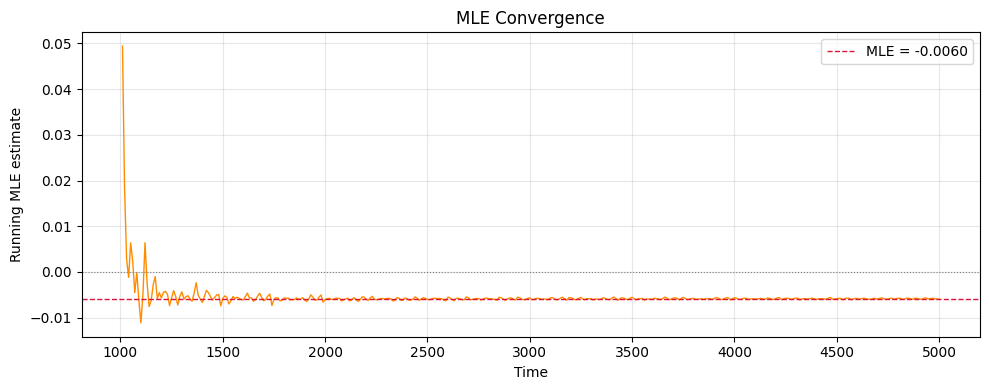

In [ ]:
PARAMS.update({
    "t_start":0,
    "t_end":5000,
    "transient_drop_frac" : 0.5,
})
t, sol, msg = simulate(t_span=[PARAMS['t_start'],PARAMS['t_end']])
t_trim, sol_trim = drop_transient(t, sol, frac=PARAMS['transient_drop_frac'])
ps = poincare_section(t, sol, PARAMS)

run = tracker.create_run(params=PARAMS, notes="SIM: trying largest obtained MLE value from 2026-04-02_11-49-53_dce2d62c8e PREVIOUS RUN INVALID")

plot_phase_portrait(sol_trim, title="Coupled DVP — Phase Portrait", save_path=run.get_path("logs"))
plot_poincare(ps, title="Coupled DVP — Poincare Section", save_path=run.get_path("logs"))

run.copy_file("3OscDVPParams.config", "")

mle, growth_log = compute_mle(PARAMS, t_span=[PARAMS['t_start'],PARAMS['t_end']])
logger = Logger(os.path.join(run.get_path("logs"), f"{run.uid}.log"))
logger.start_session()
logger(msg)
logger(f"MLE = {mle:.4f}")
plot_mle_convergence(growth_log, mle, save_path=run.get_path("logs"))
logger.end_session()

### Sweeping parameter space to find MLE regions greater than 0.2
Supports two coupling modes:
- `independent`: sweeps `k12, k13, k23` separately (7D LHS)
- `common`: sweeps a single `k` applied to all pairs (5D LHS)

In [ ]:
from scipy.stats import qmc
from joblib import Parallel, delayed

def mle_for_params(param_sample, coupling_mode='independent'):
    if coupling_mode == 'independent':
        F1, F2, F3, Omega, k12, k13, k23 = param_sample
    else:
        F1, F2, F3, Omega, k = param_sample
        k12, k13, k23 = k, k, k

    params = {
        # mu must stay low (~0.1) for chaos to emerge
        'mu1': 0.1, 'mu2': 0.08, 'mu3': 0.12,
        'omega1': 1.0, 'omega2': 1.02, 'omega3': 0.97,
        'alpha1': 1.0, 'alpha2': 1.0, 'alpha3': 1.0,
        'k12': k12, 'k13': k13, 'k23': k23,
        'F1': F1, 'F2': F2, 'F3': F3,
        'Omega': Omega,
    }

    try:
        mle, _ = compute_mle(params, t_span=(0, 500), ts_per_sec=10)
        if coupling_mode == 'independent':
            return (F1, F2, F3, Omega, k12, k13, k23, mle)
        else:
            return (F1, F2, F3, Omega, k, mle)
    except Exception as e:
        print(f"Failed: {e}")
        if coupling_mode == 'independent':
            return (F1, F2, F3, Omega, k12, k13, k23, np.nan)
        else:
            return (F1, F2, F3, Omega, k, np.nan)

def sweep_mle_lhs(sweep_params, n_samples=10000, n_jobs=-1, seed=42, coupling_mode='independent'):
    # ---- SEARCH SPACE ----
    # coupling_mode='independent': 7D LHS over [F1, F2, F3, Omega, k12, k13, k23]
    # coupling_mode='common':      5D LHS over [F1, F2, F3, Omega, k]
    bounds_low  = sweep_params["bounds_low"]
    bounds_high = sweep_params["bounds_high"]
    d = len(bounds_low)

    sampler = qmc.LatinHypercube(d=d, seed=seed)
    sample  = sampler.random(n=n_samples)
    samples = qmc.scale(sample, bounds_low, bounds_high)

    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(mle_for_params)(s, coupling_mode) for s in samples
    )

    return np.array(results)

In [ ]:
# ---- SEARCH SPACE (7D: independent coupling) ----
# Swept: F1, F2, F3 in [0.5, 8.0], Omega in [0.5, 2.0], k12/k13/k23 in [0.01, 1.0]
# Fixed: mu1=0.1, mu2=0.08, mu3=0.12, omega1=1.0, omega2=1.02, omega3=0.97, alpha=1.0

COUPLING_MODE = 'independent'  # 'independent' or 'common'

sweep_params = {
    "mle_threshold" : 0.2,
    "n_samples" : 5000,
    "seed" : 42,
    "bounds_low"  : [0.5, 0.5, 0.5, 0.5, 0.01, 0.01, 0.01],
    "bounds_high" : [8.0, 8.0, 8.0, 2.0, 1.0,  1.0,  1.0 ]
}

# For common coupling mode, use 5D bounds instead:
# sweep_params = {
#     "mle_threshold" : 0.2,
#     "n_samples" : 10000,
#     "seed" : 42,
#     "bounds_low"  : [0.5, 0.5, 0.5, 0.5, 0.01],
#     "bounds_high" : [8.0, 8.0, 8.0, 2.0, 1.0 ]
# }

run = tracker.create_run(sweep_params, f"3OscDVP {int(sweep_params['n_samples']/1000)}k sample-LHS MLE sweep ({COUPLING_MODE}), threshold={sweep_params['mle_threshold']}")
logger = Logger(os.path.join(run.get_path("logs"), f"{run.uid}.log"))
logger.start_session()
logger(f"Coupling mode: {COUPLING_MODE}")
logger(f"Sweeping {len(sweep_params['bounds_low'])}D parameter space, n_samples={sweep_params['n_samples']}")

results = sweep_mle_lhs(sweep_params, n_samples=sweep_params["n_samples"],
                         seed=sweep_params["seed"], coupling_mode=COUPLING_MODE)
run.save_binary(f"{run.get_path("data")}\\{run.uid}.pkl", results[results[:,-1] > 0.05])

threshold = sweep_params["mle_threshold"]
chaotic = results[results[:, -1] > threshold]

mle_col = results[:, -1]
valid = mle_col[~np.isnan(mle_col)]
logger(f"MLE stats: max={np.max(valid):.4f}, mean={np.mean(valid):.4f}, std={np.std(valid):.4f}")
logger(f"Positive MLE count: {np.sum(valid > 0)} / {len(valid)}")
logger(f"MLE > 0.05: {np.sum(valid > 0.05)}, MLE > 0.1: {np.sum(valid > 0.1)}, MLE > 0.2: {np.sum(valid > 0.2)}")
logger(f"Found {len(chaotic)} chaotic parameter sets above MLE={threshold}")
logger("Top 20 sorted descending by MLE:")
logger(str(chaotic[chaotic[:, -1].argsort()[::-1]][:20]))
logger.end_session()

Logger initialized with file 2026-04-02_11-49-53_dce2d62c8e.log
[2026-04-02 11:49:53] [INFO] [DEF]: Coupling mode: independent
[2026-04-02 11:49:53] [INFO] [DEF]: Sweeping 7D parameter space, n_samples=5000


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   31.6s
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 256 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done 616 tasks      | elapsed:  6.9min
[Parallel(n_jobs=-1)]: Done 850 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 1120 tasks      | elapsed: 12.6min
[Parallel(n_jobs=-1)]: Done 1426 tasks      | elapsed: 16.1min
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed: 20.0min
[Parallel(n_jobs=-1)]: Done 2146 tasks      | elapsed: 24.3min
[Parallel(n_jobs=-1)]: Done 2560 tasks      | elapsed: 29.1min
[Parallel(n_jobs=-1)]: Done 3010 tasks      | elapsed: 34.2min
[Parallel(n_jobs=-1)]: Done 3496 tasks      | elapsed: 39.8min
[Parallel(n_jobs=-1)]: Done 4018 tasks      | elapsed: 45.8min
[Parallel(n_jobs=-1)]: Done 4576 tasks      | e

[2026-04-02 12:46:59] [INFO] [DEF]: MLE stats: max=0.0876, mean=-0.0239, std=0.0324
[2026-04-02 12:46:59] [INFO] [DEF]: Positive MLE count: 1296 / 5000
[2026-04-02 12:46:59] [INFO] [DEF]: MLE > 0.05: 30, MLE > 0.1: 0, MLE > 0.2: 0
[2026-04-02 12:46:59] [INFO] [DEF]: Found 0 chaotic parameter sets above MLE=0.2
[2026-04-02 12:46:59] [INFO] [DEF]: Top 20 sorted descending by MLE:
[2026-04-02 12:46:59] [INFO] [DEF]: []


[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed: 57.1min finished


In [21]:
np.sum([results[i][-1] > 0 for i in range(len(results))])

np.int64(1296)

In [37]:
results[results[:,-1] > 0.05]

array([[7.4228209 , 2.01930783, 0.58182442, 0.52118876, 0.6230225 ,
        0.85711451, 0.67432509, 0.05639467],
       [1.87587624, 3.74699968, 7.05150398, 0.80806183, 0.66989663,
        0.0292356 , 0.74548164, 0.07090707],
       [5.42205133, 2.03276076, 0.81699001, 0.83681882, 0.17784998,
        0.19588989, 0.71818019, 0.06243242],
       [0.68608408, 3.69435981, 0.55564834, 1.25147051, 0.31926749,
        0.64900117, 0.89391932, 0.06211324],
       [2.33759647, 5.98280275, 5.48814837, 0.79815873, 0.42291631,
        0.6691298 , 0.03525868, 0.05233234],
       [3.7052422 , 1.42492354, 6.56619777, 0.7869389 , 0.77751625,
        0.25972096, 0.02429003, 0.06155163],
       [7.49873332, 1.84590291, 1.07906361, 1.1938092 , 0.53331674,
        0.04061508, 0.43566045, 0.051507  ],
       [1.29048551, 1.43534878, 4.82436572, 0.82869267, 0.5021837 ,
        0.06268456, 0.88676775, 0.06864873],
       [5.28667278, 4.20561442, 0.69937682, 1.15515176, 0.33371478,
        0.35311262, 0.127220